In [1]:
# %load_ext autoreload
# %autoreload 2

import os

from functools import partial

if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "jax"

import blackjax
import bayesflow as bf
import jax
import jax.numpy as jnp
import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from priors import truncated_normal_rvs
from mcmc import model_nle, warmup, inference_loop_multiple_chains
from plots import create_profile_likelihood_plot, create_pushforward_plot_rdmc
from rdmc import rdmc_experiment_simple


INFO:2025-11-14 16:56:28,624:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [2]:
def prior_fun_train(
    drift_c_intercept_loc=0.05,
    drift_c_intercept_scale=0.05,
    drift_c_slope_loc=0.5,
    drift_c_slope_scale=0.1,
    amp_shape=10,
    amp_scale=2,
    tau_shape=8,
    tau_scale=10,
    sd_true_shape=80,
    sd_true_scale=0.05,
    threshold_shape=100,
    threshold_scale=0.7,
    t0_loc=300,
    t0_scale=200,
    rng=np.random.default_rng(2025),
):
    drift_c_intercept = truncated_normal_rvs(drift_c_intercept_loc, drift_c_intercept_scale, random_state=rng)
    drift_c_slope = truncated_normal_rvs(drift_c_slope_loc, drift_c_slope_scale, random_state=rng)
    amp = rng.gamma(shape=amp_shape, scale=amp_scale)
    tau = rng.gamma(shape=tau_shape, scale=tau_scale)
    s_true = rng.gamma(shape=sd_true_shape, scale=sd_true_scale)
    b = rng.gamma(shape=threshold_shape, scale=threshold_scale)
    t0 = truncated_normal_rvs(t0_loc, t0_scale, random_state=rng)

    return {
        "v_c_intercept": drift_c_intercept,
        "v_c_slope": drift_c_slope,
        "amp": amp,
        "tau": tau,
        "s_true": s_true,
        "b": b,
        "t0": t0
    }

def simulator_fun(**kwargs):
    return rdmc_experiment_simple(**kwargs, t_max=5000, seed=2025, a_shape=2, s_false=4)


def meta(batch_size):
    num_obs = np.random.default_rng(2025).integers(250, 750)

    return dict(num_obs=num_obs)

simulator = bf.simulators.make_simulator([prior_fun_train, simulator_fun], meta_fn=meta)

In [3]:
def prior_log_prob(x):
    x = jnp.exp(x)
    # x shape: (..., 7)
    v_c_intercept_lp = jax.scipy.stats.norm.logpdf(x[..., 0], loc=0.05, scale=0.05)
    v_c_slope_lp     = jax.scipy.stats.norm.logpdf(x[..., 1], loc=0.5, scale=0.1)
    tau_lp           = jax.scipy.stats.gamma.logpdf(x[..., 2], a=8, scale=10)
    amp_lp           = jax.scipy.stats.gamma.logpdf(x[..., 3], a=10, scale=2)
    s_true_lp        = jax.scipy.stats.gamma.logpdf(x[..., 4], a=80, scale=0.05)
    b_lp             = jax.scipy.stats.gamma.logpdf(x[..., 5], a=100, scale=0.7)
    t0_lp            = jax.scipy.stats.norm.logpdf(x[..., 6], loc=300, scale=200)
    return (
        v_c_intercept_lp
        + v_c_slope_lp
        + tau_lp
        + amp_lp
        + s_true_lp
        + b_lp
        + t0_lp
    )

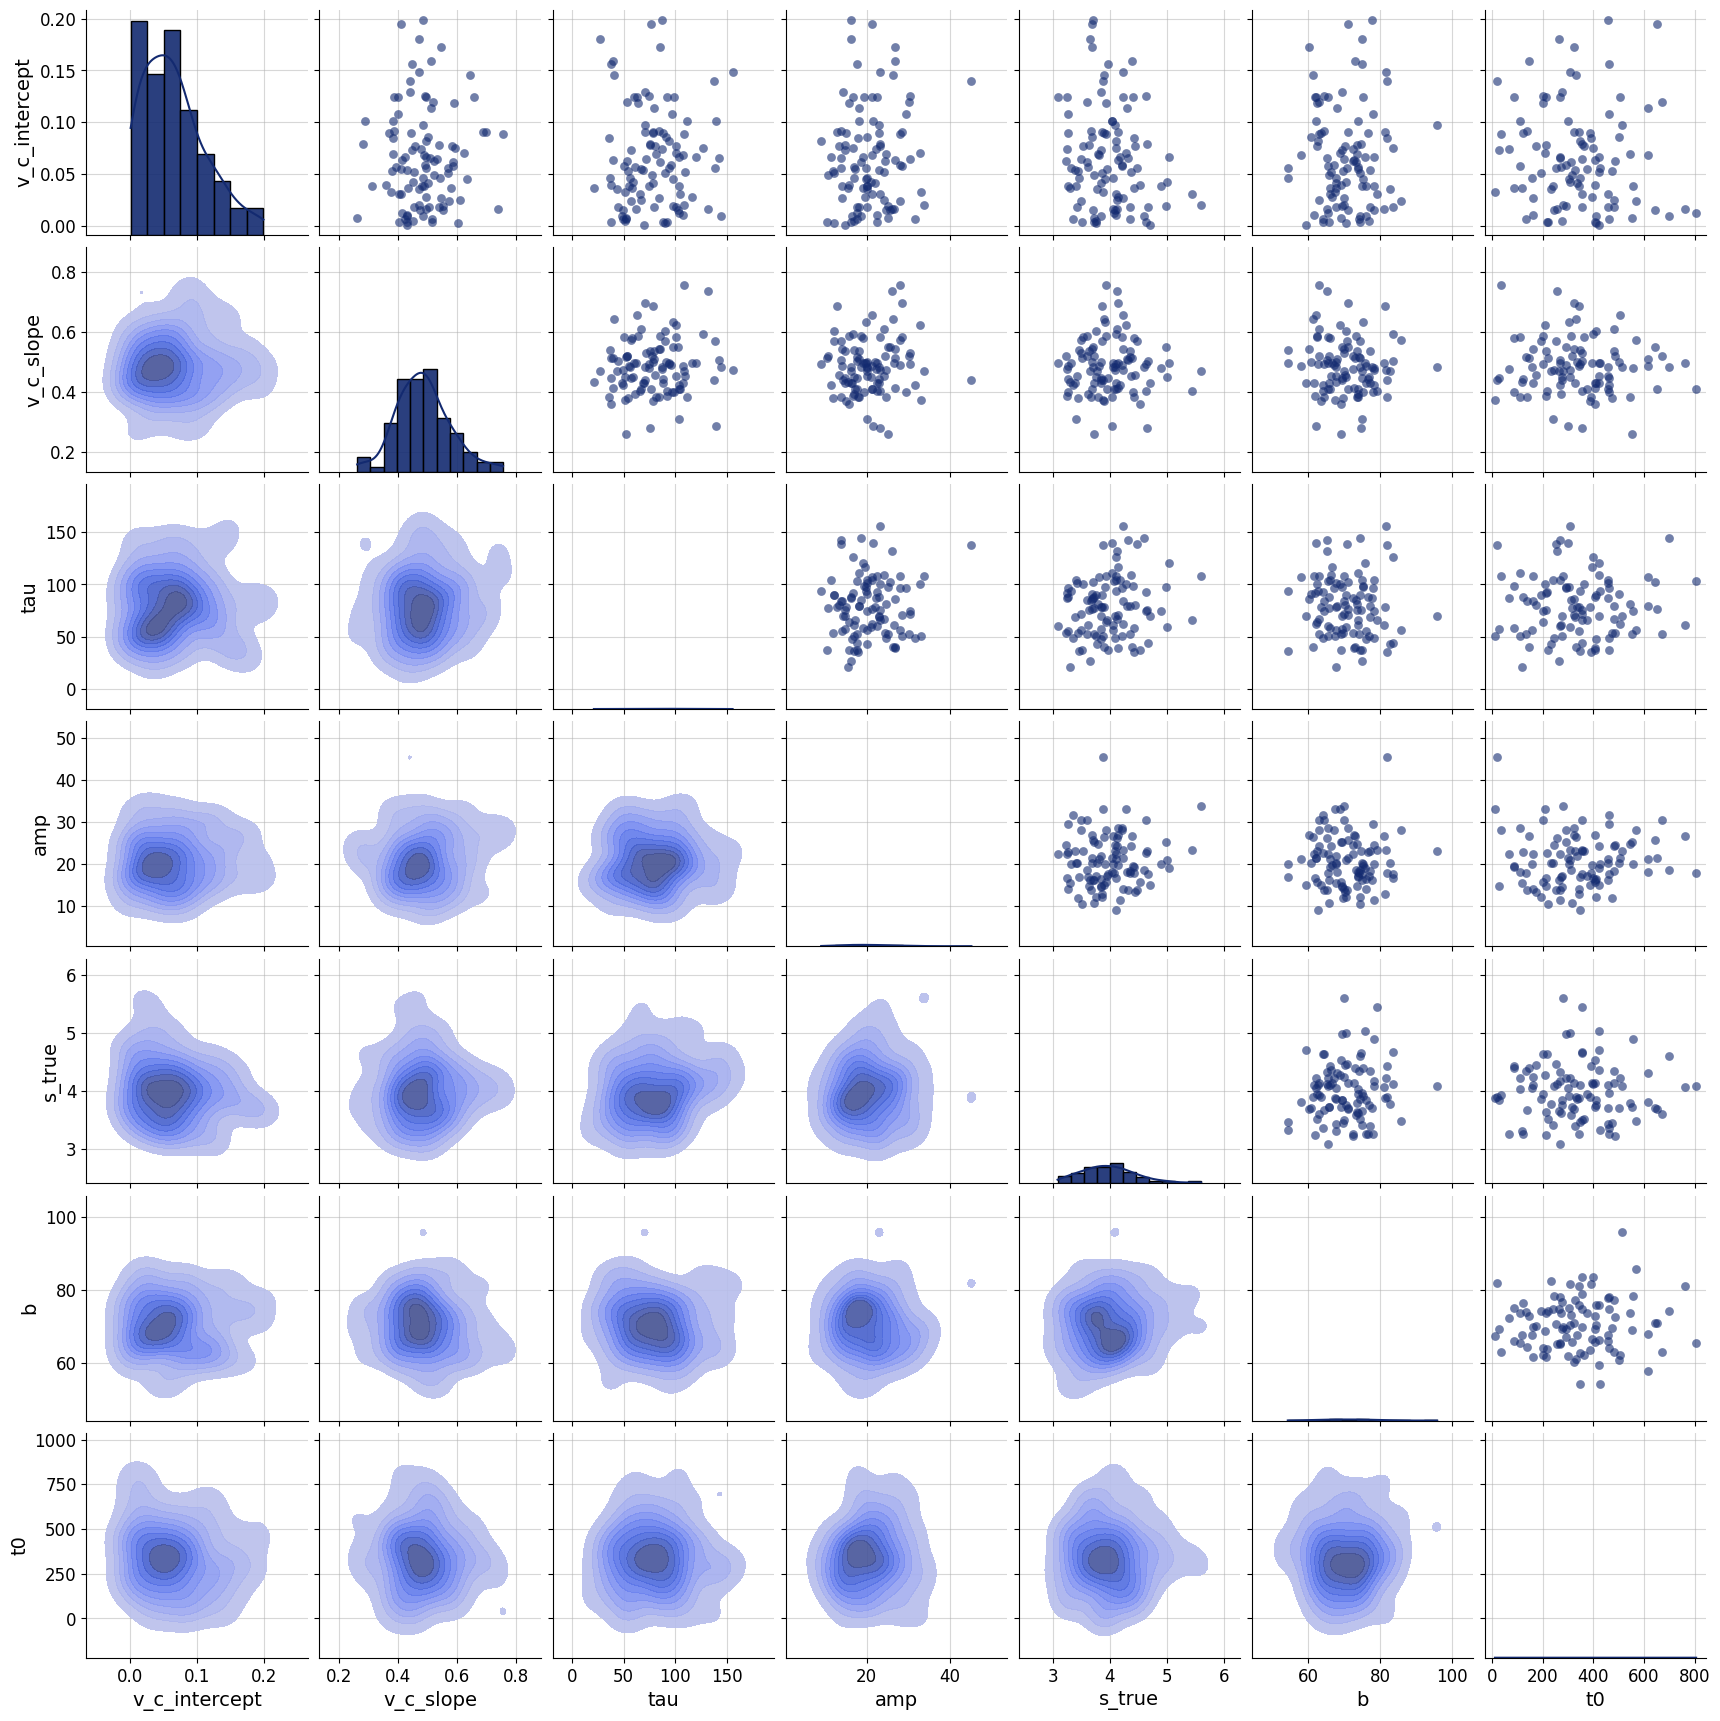

In [4]:
param_names = ["v_c_intercept", "v_c_slope", "tau", "amp", "s_true", "b", "t0"]

data = simulator.sample(100)

fig = bf.diagnostics.plots.pairs_samples(
    samples=data,
    variable_keys=param_names,
    variable_names=param_names
)

In [5]:
approximator = keras.saving.load_model("checkpoints/rdmc_nle_spline_shallow_20.keras")

In [6]:
approximator.inference_network.subnet_kwargs

{'depth': 2, 'dropout': 0.05, 'transform': 'spline'}

In [7]:
test_data = simulator.sample(1)
prior_draws = np.array([test_data[p] for p in param_names]).squeeze()
approximator.log_prob(test_data).sum()

-1218.6042

In [8]:
init_position = np.array([0.1, 0.5, 50, 20, 4, 75, 300])

In [9]:
model_nle(test_data, approximator)(jnp.log(prior_draws)), model_nle(test_data, approximator)(jnp.log(init_position))

(Array(-1218.6648, dtype=float32), Array(-6016.657, dtype=float32))

In [10]:
ll_fun = model_nle(test_data, approximator)

def likelihood(x):
    return ll_fun(x) + prior_log_prob(x)

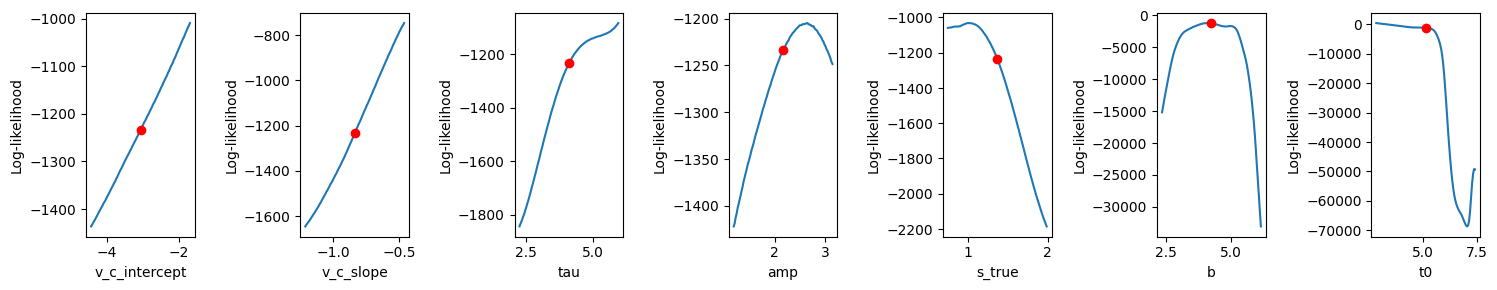

In [11]:
_ = create_profile_likelihood_plot(likelihood, jnp.log(prior_draws), param_names)

In [13]:
rng_key = jax.random.key(2025)
    
rng_key, warmup_key = jax.random.split(rng_key)

kernel, last_state, warmup_parameters = warmup(
    blackjax.nuts,
    likelihood,
    jnp.log(init_position),
    500,
    warmup_key,
    # target_acceptance_rate=0.9,
    progress_bar=True
)

Running window adaptation


In [14]:
warmup_parameters

{'step_size': Array(8.230157e-06, dtype=float32, weak_type=True),
 'inverse_mass_matrix': Array([2.4488148e-05, 2.4398354e-05, 2.4407809e-05, 2.4412269e-05,
        2.4414428e-05, 2.4393132e-05, 2.4445568e-05], dtype=float32)}

In [15]:
for p1, p2, p3 in zip(np.exp(last_state.position), init_position, prior_draws):
    print(p1, p2, p3)

0.09971678 0.1 0.04655966929428123
0.4901192 0.5 0.4333307554599998
49.50594 50.0 60.693803093803425
20.000841 20.0 8.705716739910784
4.081477 4.0 3.9404136847538136
75.36237 75.0 70.83526527404787
278.93387 300.0 165.77904391072232


In [16]:
num_chains = 4

last_states = jax.vmap(lambda x: last_state)(np.arange(num_chains))

trace = inference_loop_multiple_chains(
    rng_key, kernel, last_states, 500, num_chains
)

In [17]:
blackjax.diagnostics.potential_scale_reduction(trace.position)

Array([0.872226 , 1.2067298, 1.0009425, 1.0278696, 1.2867671,       inf,
             nan], dtype=float32)

INFO:arviz.preview:arviz_base not installed
INFO:arviz.preview:arviz_stats not installed
INFO:arviz.preview:arviz_plots not installed
/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/mluken/Repositories/racing-diffusion-c

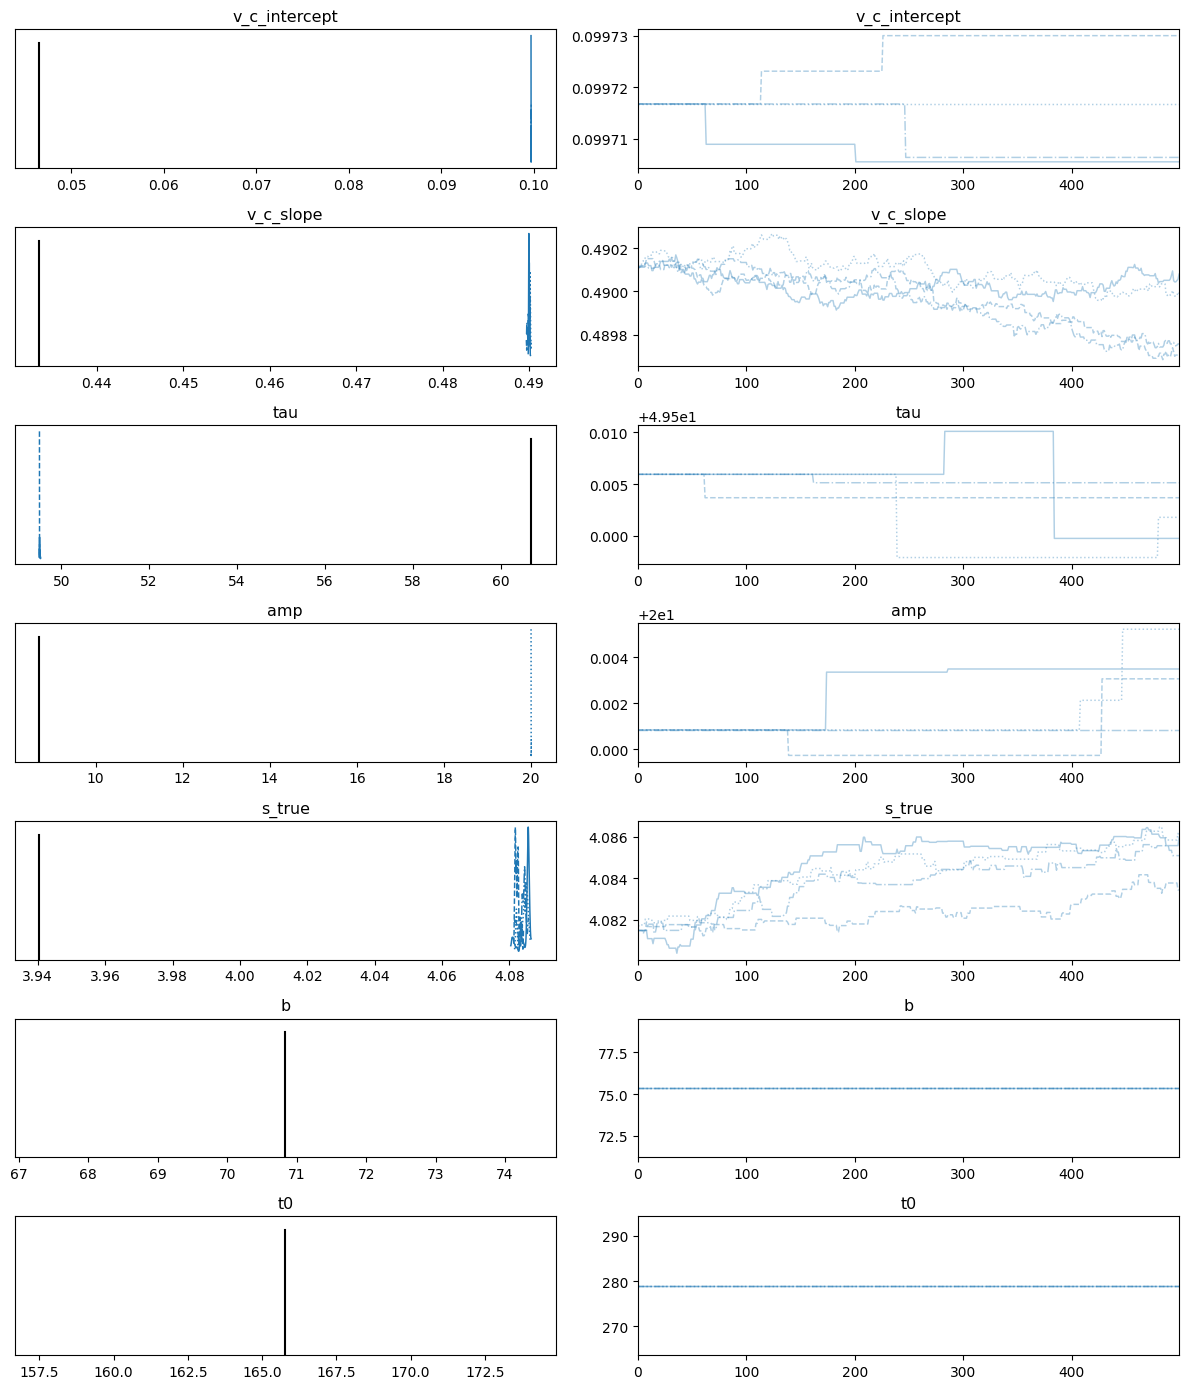

In [18]:
import matplotlib.pyplot as plt
import arviz as az

reference_values = {
    key: val for key, val in zip(param_names, prior_draws)
}

idata = az.from_dict(
    posterior={k: v
               for k, v in zip(param_names, np.moveaxis(np.exp(trace.position), (0, 1, 2), (2, 1, 0)))})
ax = az.plot_trace(idata)

for i, p in enumerate(prior_draws):
    ax[i, 0].axvline(p, 0, 0.9, color="k")

plt.tight_layout()

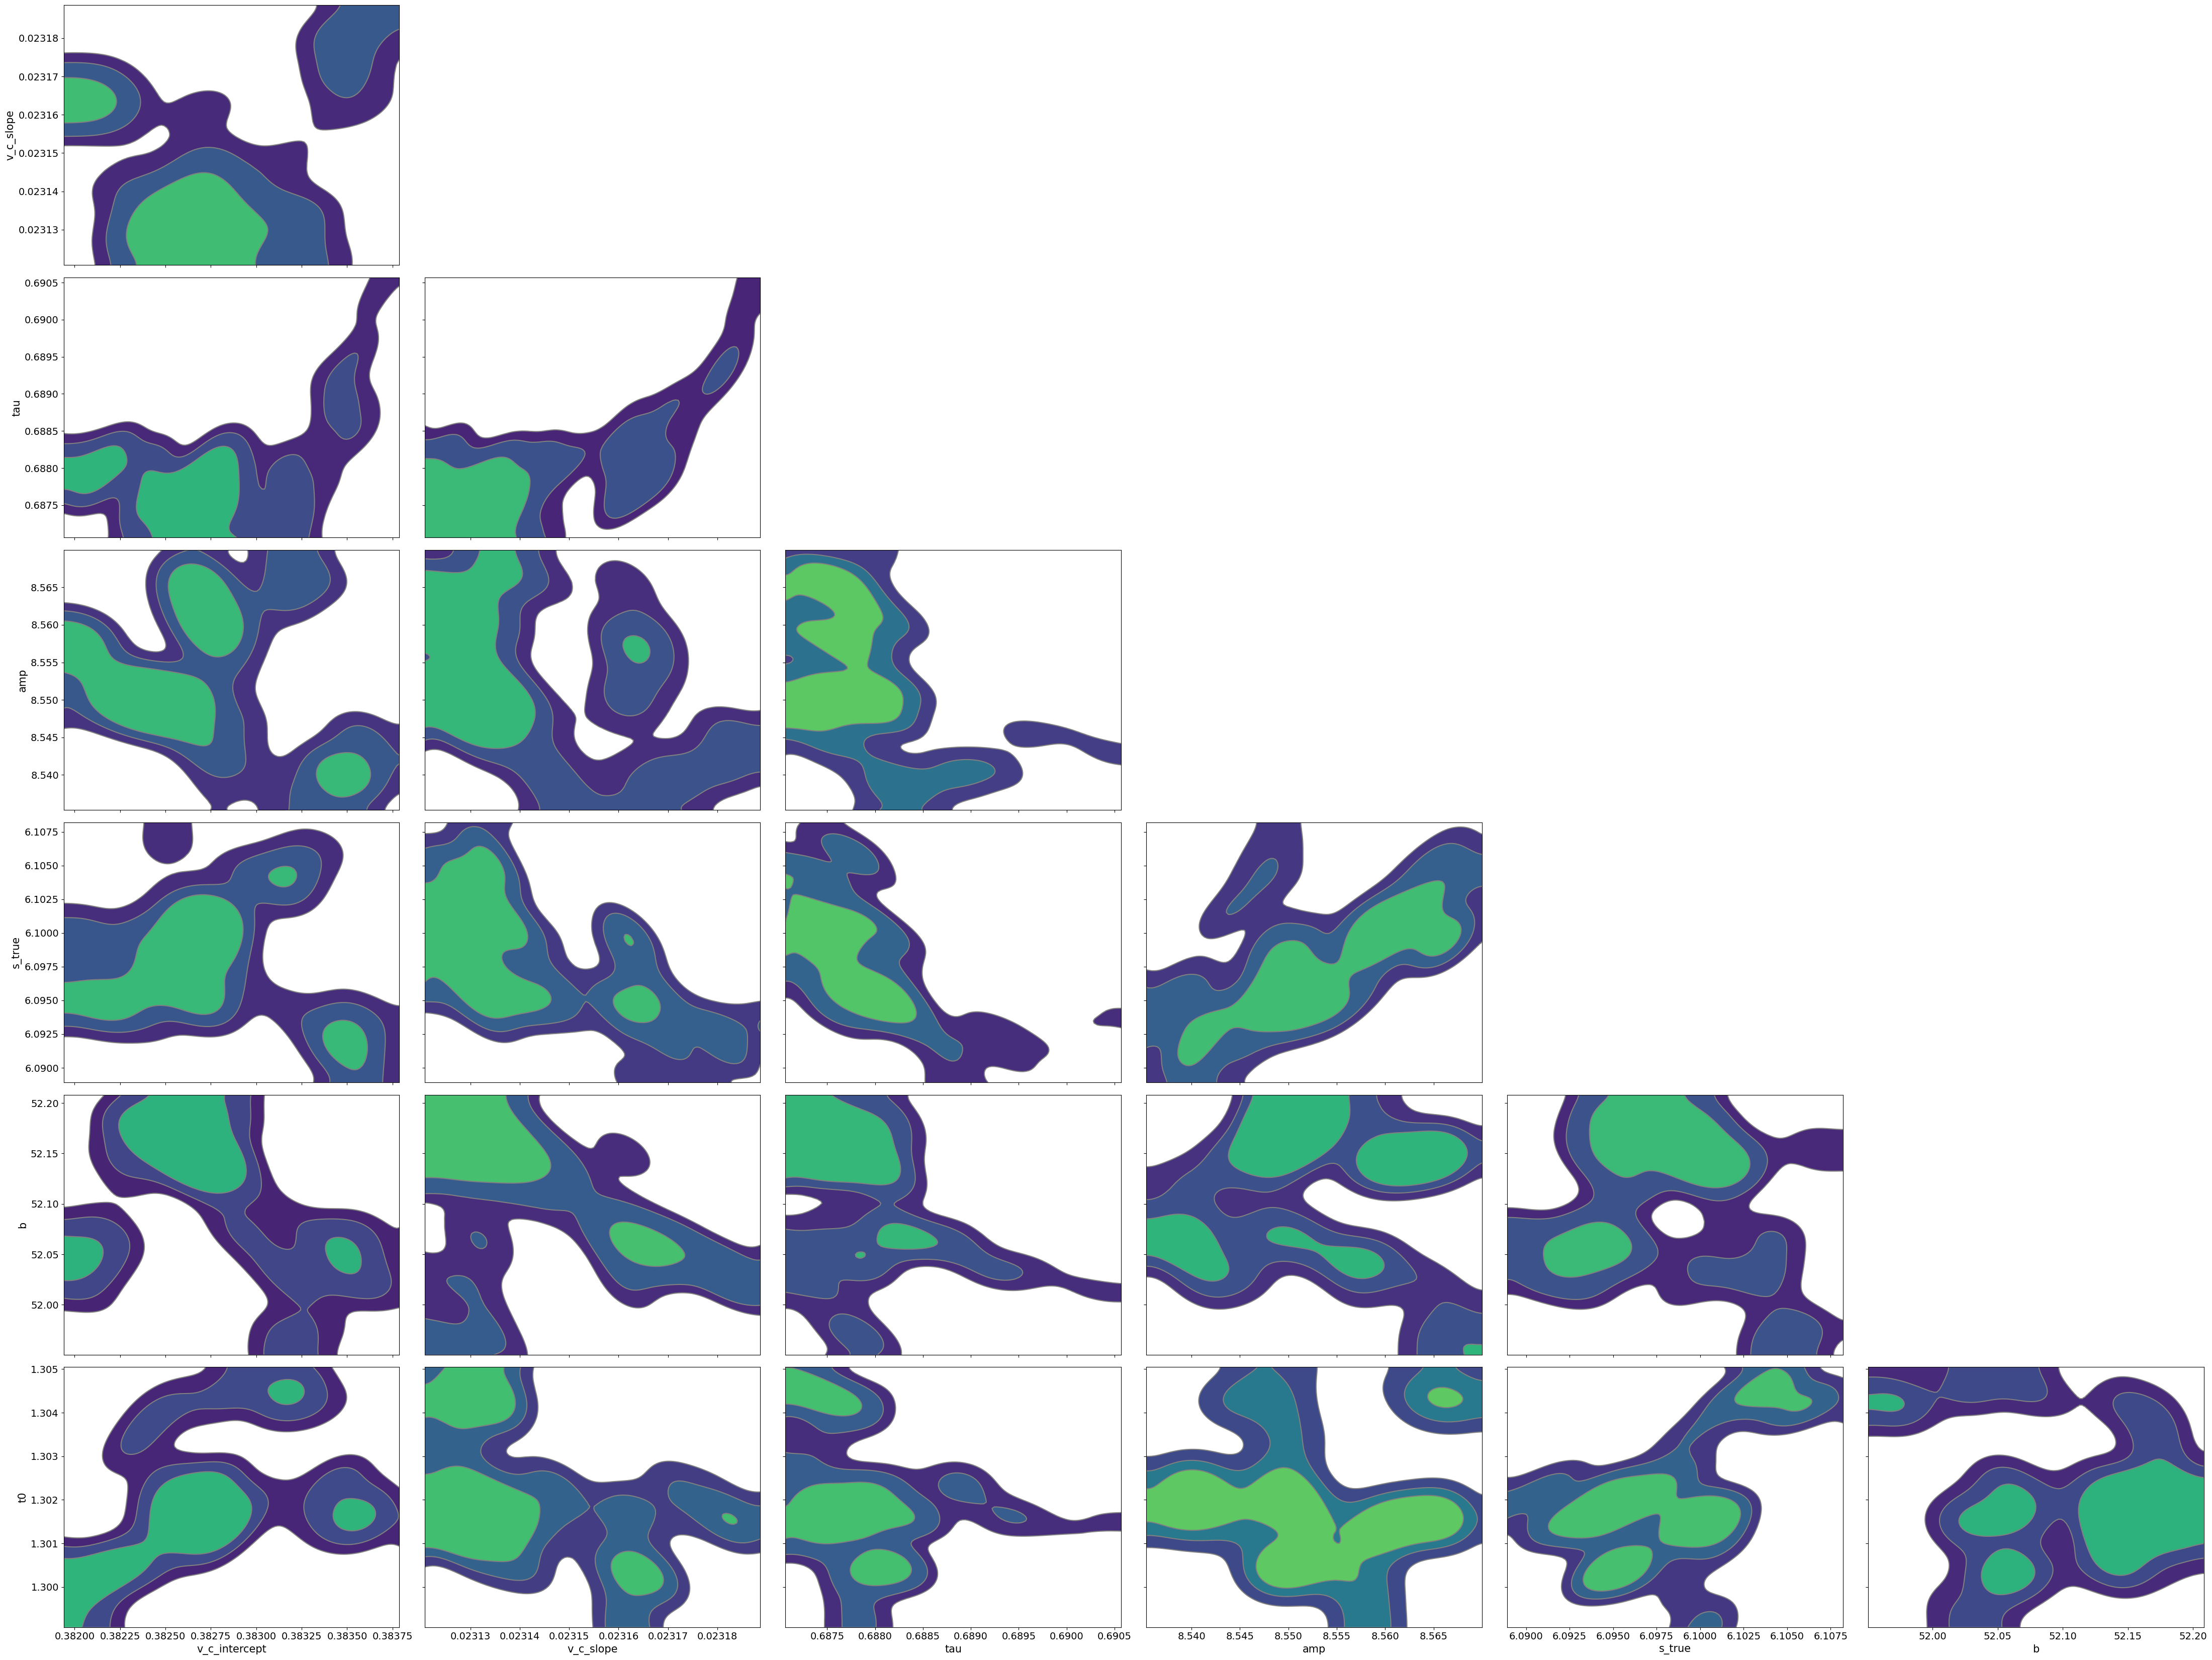

In [87]:
az.plot_pair(idata, kind="kde")
plt.tight_layout()